In [1]:
from __future__ import annotations

import csv
import gc
import importlib
import json
import math
import os
import re
import shutil
import subprocess
import sys
from pathlib import Path
from typing import Any, Optional

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Keep Hugging Face model cache in Kaggle temp to reduce /kaggle/working disk pressure.
os.environ["HF_HOME"] = "/kaggle/temp/huggingface"
os.environ["TRANSFORMERS_CACHE"] = "/kaggle/temp/huggingface"
os.environ["HF_HUB_CACHE"] = "/kaggle/temp/huggingface/hub"


def ensure_package(import_name: str, pip_name: str) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "-U", pip_name]
        )


ensure_package("transformers", "transformers>=4.44.0")
ensure_package("accelerate", "accelerate>=0.33.0")
ensure_package("bitsandbytes", "bitsandbytes>=0.43.1")
ensure_package("tqdm", "tqdm")
ensure_package("pandas", "pandas")
ensure_package("matplotlib", "matplotlib")
ensure_package("seaborn", "seaborn")

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    set_seed,
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.5 MB/s eta 0:00:00


In [2]:
TARGET_MODEL = "Qwen/Qwen2.5-7B-Instruct"

LANGUAGE_FILES = {
    "english": "ipip-50_english.json",
    "burmese": "ipip-50_burmese.json",
}

NUM_SESSIONS = 20
MAX_NEW_TOKENS = 8
TEMPERATURE = 0.7
DO_SAMPLE = True
BASE_SEED = 20260705

RUN_EVALUATION = True
RUN_VISUALIZATION = True
CLEAN_MODEL_CACHE_AFTER_RUN = True

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
HF_CACHE_ROOT = Path("/kaggle/temp/hf_model_cache")

TRAITS = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Neuroticism",
    "Openness",
]

LANGUAGES = ["english", "burmese"]

LANGUAGE_COLORS = {
    "english": "#E6862A",
    "burmese": "#2F80C1",
}


def model_slug(model_id: str) -> str:
    slug = model_id.split("/")[-1].lower()
    slug = re.sub(r"[^a-z0-9]+", "_", slug).strip("_")
    return slug


MODEL_SLUG = model_slug(TARGET_MODEL)

OUTPUT_CSV = OUTPUT_DIR / f"llm_persona_results_{MODEL_SLUG}.csv"
TRAIT_SCORES_CSV = OUTPUT_DIR / f"llm_persona_trait_scores_{MODEL_SLUG}.csv"
SUMMARY_CSV = OUTPUT_DIR / f"llm_persona_summary_{MODEL_SLUG}.csv"

TRAIT_BARS_PNG = OUTPUT_DIR / f"llm_persona_traits_{MODEL_SLUG}.png"
RADAR_PNG = OUTPUT_DIR / f"radar_persona_profiles_{MODEL_SLUG}.png"
DRIFT_HEATMAP_PNG = OUTPUT_DIR / f"persona_drift_heatmap_{MODEL_SLUG}.png"
PARSE_FAILURE_PNG = OUTPUT_DIR / f"parse_failure_rates_{MODEL_SLUG}.png"
SESSION_STABILITY_PNG = OUTPUT_DIR / f"session_stability_{MODEL_SLUG}.png"

CSV_COLUMNS = [
    "model",
    "language",
    "session",
    "item_id",
    "trait",
    "keying",
    "raw_response",
    "parsed_score",
    "final_score",
    "parse_failed",
]

In [3]:
def get_hf_token() -> Optional[str]:
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
    if token:
        return token

    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        return None


HF_TOKEN = get_hf_token()

if HF_TOKEN:
    print("HF token detected.")
else:
    print("No HF token detected. Public models may still work, but downloads can be slower or rate-limited.")

HF token detected.


In [4]:
def find_dataset_file(filename: str) -> Path:
    direct_candidates = [
        Path.cwd() / filename,
        OUTPUT_DIR / filename,
    ]

    for path in direct_candidates:
        if path.exists():
            return path

    input_root = Path("/kaggle/input")
    if input_root.exists():
        matches = sorted(input_root.rglob(filename))
        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"Could not find {filename}. Put it in /kaggle/working or attach it as a Kaggle input dataset."
    )


def first_present(record: dict[str, Any], keys: list[str], default: Any = None) -> Any:
    for key in keys:
        if key in record:
            return record[key]
    return default


def load_ipip_items(filename: str) -> list[dict[str, Any]]:
    path = find_dataset_file(filename)
    print(f"Loading dataset file: {path}")

    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, dict):
        if "questions" in data:
            raw_items = data["questions"]
        elif "items" in data:
            raw_items = data["items"]
        else:
            list_values = [v for v in data.values() if isinstance(v, list)]
            if not list_values:
                raise ValueError(f"{path} does not contain a questions/items list.")
            raw_items = list_values[0]

    elif isinstance(data, list):
        raw_items = data

    else:
        raise ValueError(f"{path} must contain a JSON object or list.")

    items = []

    for idx, record in enumerate(raw_items, start=1):
        if not isinstance(record, dict):
            raise ValueError(f"Item {idx} in {path} is not an object.")

        item_id = first_present(record, ["id", "item_id", "number"], idx)
        text = first_present(record, ["text", "item", "statement", "sentence", "question"])
        trait = first_present(record, ["trait", "factor", "domain"])
        keying = first_present(record, ["keying", "key", "direction"])

        if not text:
            raise ValueError(f"Item {idx} in {path} has no text field.")

        if trait is None:
            raise ValueError(f"Item {idx} in {path} has no trait field.")

        if keying not in {"+", "-"}:
            raise ValueError(f"Item {idx} in {path} has invalid keying: {keying!r}")

        items.append(
            {
                "item_id": item_id,
                "text": str(text),
                "trait": str(trait),
                "keying": keying,
            }
        )

    if len(items) != 50:
        raise ValueError(f"{path} contains {len(items)} items, expected exactly 50.")

    return items


def validate_parallel_items(
    english: list[dict[str, Any]],
    burmese: list[dict[str, Any]],
) -> None:
    for en, my in zip(english, burmese):
        if str(en["item_id"]) != str(my["item_id"]):
            raise ValueError(f"Parallel item ID mismatch: {en['item_id']} vs {my['item_id']}")

        if en["trait"] != my["trait"]:
            raise ValueError(f"Trait mismatch for item {en['item_id']}: {en['trait']} vs {my['trait']}")

        if en["keying"] != my["keying"]:
            raise ValueError(f"Keying mismatch for item {en['item_id']}: {en['keying']} vs {my['keying']}")

In [5]:
ENGLISH_SYSTEM_PROMPT = (
    "You are completing a psychometric inventory as the respondent. "
    "Use the standard IPIP five-point response scale, where the lowest number means "
    "very inaccurate and the highest number means very accurate. "
    "Output ONLY one single integer from 1 to 5. "
    "Do not output words, punctuation, explanations, labels, or more than one number."
)

BURMESE_SYSTEM_PROMPT = (
    "သင်သည် ကိုယ်ရည်ကိုယ်သွေး မေးခွန်းလွှာကို ဖြေဆိုနေသူဖြစ်သည်။ "
    "စာကြောင်းတစ်ခုစီအတွက် အနိမ့်ဆုံးအဆင့်မှ အမြင့်ဆုံးအဆင့်အထိ ငါးဆင့်စကေးဖြင့် ဖြေပါ။ "
    "အဖြေမှာ 1 မှ 5 အတွင်း ကိန်းဂဏန်းတစ်လုံးတည်းသာ ဖြစ်ရမည်။ "
    "စကားလုံး၊ ပုဒ်ဖြတ်ပုဒ်ရပ်၊ ရှင်းလင်းချက်၊ တံဆိပ်စသည် မထည့်ပါနှင့်။"
)

BURMESE_FEWSHOT_USER = "စာကြောင်း: ငါက ကိုယ်ပိုင်ပစ္စည်းတွေကို ဟိုဟိုသည်သည် ပစ်ထားတတ်တယ်။"
BURMESE_FEWSHOT_ASSISTANT = "2"


def build_messages(language: str, item_text: str) -> list[dict[str, str]]:
    if language == "english":
        return [
            {"role": "system", "content": ENGLISH_SYSTEM_PROMPT},
            {"role": "user", "content": f"Sentence: {item_text}"},
        ]

    if language == "burmese":
        return [
            {"role": "system", "content": BURMESE_SYSTEM_PROMPT},
            {"role": "user", "content": BURMESE_FEWSHOT_USER},
            {"role": "assistant", "content": BURMESE_FEWSHOT_ASSISTANT},
            {"role": "user", "content": f"စာကြောင်း: {item_text}"},
        ]

    raise ValueError(f"Unsupported language: {language}")


BURMESE_DIGITS = {
    "၁": 1,
    "၂": 2,
    "၃": 3,
    "၄": 4,
    "၅": 5,
}

WESTERN_DIGITS = {
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
}

VALID_SINGLE_DIGITS = {**WESTERN_DIGITS, **BURMESE_DIGITS}


def parse_strict_score(raw_response: str) -> tuple[float, bool]:
    stripped = "" if raw_response is None else str(raw_response).strip()

    if len(stripped) == 1 and stripped in VALID_SINGLE_DIGITS:
        return float(VALID_SINGLE_DIGITS[stripped]), False

    return math.nan, True


def parser_self_test() -> None:
    passing = ["1", " 5 ", "၁", "\n၅\t"]
    failing = ["2.", "Answer: 2", "1=Very inaccurate", "1 2", "၅။", "", "10"]

    for value in passing:
        score, failed = parse_strict_score(value)
        assert not failed and 1 <= score <= 5, value

    for value in failing:
        score, failed = parse_strict_score(value)
        assert failed and math.isnan(score), value


parser_self_test()
print("Parser self-test passed.")

Parser self-test passed.


In [6]:
def ensure_output_csv(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    if not path.exists() or path.stat().st_size == 0:
        with path.open("w", encoding="utf-8", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
            writer.writeheader()
            f.flush()
            os.fsync(f.fileno())


def load_completed_keys(path: Path) -> set[tuple[str, str, int, str]]:
    completed: set[tuple[str, str, int, str]] = set()

    if not path.exists() or path.stat().st_size == 0:
        return completed

    with path.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)

        for row in reader:
            completed.add(
                (
                    row["model"],
                    row["language"],
                    int(row["session"]),
                    str(row["item_id"]),
                )
            )

    return completed


def append_result(path: Path, row: dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
        writer.writerow(row)
        f.flush()
        os.fsync(f.fileno())

In [7]:
def safe_model_cache_dir(model_id: str) -> Path:
    return HF_CACHE_ROOT / model_id.replace("/", "__")


def get_input_device(model: torch.nn.Module) -> torch.device:
    return model.get_input_embeddings().weight.device


def load_model_and_tokenizer(model_id: str):
    cache_dir = safe_model_cache_dir(model_id)
    cache_dir.mkdir(parents=True, exist_ok=True)

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        token=HF_TOKEN,
        trust_remote_code=True,
        use_fast=True,
        cache_dir=str(cache_dir),
    )

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    tokenizer.padding_side = "left"

    if not getattr(tokenizer, "chat_template", None):
        raise ValueError(
            f"{model_id} tokenizer has no chat_template. Use an instruct/chat model with a tokenizer chat template."
        )

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        token=HF_TOKEN,
        trust_remote_code=True,
        cache_dir=str(cache_dir),
        quantization_config=quant_config,
        torch_dtype=torch.float16,
        device_map="auto",
        low_cpu_mem_usage=True,
        attn_implementation="sdpa",
    )

    model.eval()
    model.generation_config.pad_token_id = tokenizer.pad_token_id

    return model, tokenizer, cache_dir


def generate_response(
    model: torch.nn.Module,
    tokenizer,
    messages: list[dict[str, str]],
) -> str:
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False,
    )

    input_device = get_input_device(model)
    inputs = {k: v.to(input_device) for k, v in inputs.items()}

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=TEMPERATURE,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )

    new_token_ids = output_ids[0, inputs["input_ids"].shape[-1]:]

    return tokenizer.decode(
        new_token_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    ).strip()


def unload_model(model: torch.nn.Module, tokenizer) -> None:
    del model
    del tokenizer

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

In [8]:
def run_evaluation() -> None:
    if not torch.cuda.is_available():
        raise RuntimeError(
            "No CUDA GPU detected. In Kaggle, enable GPU accelerator before running this notebook."
        )

    torch.backends.cuda.matmul.allow_tf32 = True

    english_items = load_ipip_items(LANGUAGE_FILES["english"])
    burmese_items = load_ipip_items(LANGUAGE_FILES["burmese"])
    validate_parallel_items(english_items, burmese_items)

    datasets = {
        "english": english_items,
        "burmese": burmese_items,
    }

    ensure_output_csv(OUTPUT_CSV)
    completed_keys = load_completed_keys(OUTPUT_CSV)

    total_expected = len(datasets) * NUM_SESSIONS * 50

    print(f"Target model: {TARGET_MODEL}")
    print(f"Writing streaming results to: {OUTPUT_CSV}")
    print(f"Already completed rows detected: {len(completed_keys)}")
    print(f"One-model grid size: {total_expected} rows")

    print(f"\nLoading model: {TARGET_MODEL}")
    model, tokenizer, cache_dir = load_model_and_tokenizer(TARGET_MODEL)

    try:
        progress = tqdm(total=total_expected, desc=TARGET_MODEL, leave=True)

        for language, items in datasets.items():
            for session in range(1, NUM_SESSIONS + 1):
                for item_position, item in enumerate(items, start=1):
                    key = (
                        TARGET_MODEL,
                        language,
                        session,
                        str(item["item_id"]),
                    )

                    if key in completed_keys:
                        progress.update(1)
                        continue

                    seed = (
                        BASE_SEED
                        + session * 10_000
                        + item_position
                        + (0 if language == "english" else 5_000)
                    )
                    set_seed(seed)

                    messages = build_messages(language, item["text"])
                    raw_response = generate_response(model, tokenizer, messages)

                    parsed_score, parse_failed = parse_strict_score(raw_response)

                    if parse_failed:
                        final_score = math.nan
                    elif item["keying"] == "-":
                        final_score = 6.0 - parsed_score
                    else:
                        final_score = parsed_score

                    row = {
                        "model": TARGET_MODEL,
                        "language": language,
                        "session": session,
                        "item_id": item["item_id"],
                        "trait": item["trait"],
                        "keying": item["keying"],
                        "raw_response": raw_response,
                        "parsed_score": parsed_score,
                        "final_score": final_score,
                        "parse_failed": parse_failed,
                    }

                    append_result(OUTPUT_CSV, row)
                    completed_keys.add(key)
                    progress.update(1)

        progress.close()

    finally:
        unload_model(model, tokenizer)

        if CLEAN_MODEL_CACHE_AFTER_RUN and cache_dir.exists():
            shutil.rmtree(cache_dir, ignore_errors=True)

    print("\nEvaluation complete.")
    print(f"Results saved to: {OUTPUT_CSV}")


if RUN_EVALUATION:
    run_evaluation()

Loading dataset file: /kaggle/input/datasets/adoro42/ipip-50/ipip-50_english.json
Loading dataset file: /kaggle/input/datasets/adoro42/ipip-50/ipip-50_burmese.json
Target model: Qwen/Qwen2.5-7B-Instruct
Writing streaming results to: /kaggle/working/llm_persona_results_qwen2_5_7b_instruct.csv
Already completed rows detected: 0
One-model grid size: 2000 rows

Loading model: Qwen/Qwen2.5-7B-Instruct


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Qwen/Qwen2.5-7B-Instruct:   0%|          | 0/2000 [00:00<?, ?it/s]


Evaluation complete.
Results saved to: /kaggle/working/llm_persona_results_qwen2_5_7b_instruct.csv


In [9]:
def set_plot_style() -> None:
    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.1,
        rc={
            "figure.dpi": 140,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )


def load_results(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Input CSV not found: {path}")

    df = pd.read_csv(path)

    missing = set(CSV_COLUMNS).difference(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    df = df[df["model"].eq(TARGET_MODEL)].copy()

    if df.empty:
        raise ValueError(f"No rows for {TARGET_MODEL} found in {path}")

    df["parsed_score"] = pd.to_numeric(df["parsed_score"], errors="coerce")
    df["final_score"] = pd.to_numeric(df["final_score"], errors="coerce")
    df["session"] = pd.to_numeric(df["session"], errors="raise").astype(int)

    return df


def compute_session_traits(df: pd.DataFrame) -> pd.DataFrame:
    session_traits = (
        df.groupby(["model", "language", "session", "trait"], observed=True)
        .agg(
            trait_mean=("final_score", "mean"),
            valid_items=("final_score", "count"),
            total_items=("final_score", "size"),
        )
        .reset_index()
    )

    return session_traits[session_traits["valid_items"] > 0].copy()


def compute_trait_summary(session_traits: pd.DataFrame) -> pd.DataFrame:
    summary = (
        session_traits.groupby(["model", "language", "trait"], observed=True)
        .agg(
            mean_score=("trait_mean", "mean"),
            sd_score=("trait_mean", "std"),
            n_sessions=("trait_mean", "count"),
        )
        .reset_index()
    )

    summary["sd_score"] = summary["sd_score"].fillna(0)

    return summary


def compute_parse_failures(df: pd.DataFrame) -> pd.DataFrame:
    failures = (
        df.assign(parse_failed=df["final_score"].isna())
        .groupby(["model", "language"], observed=True)
        .agg(
            total_items=("final_score", "size"),
            failed_items=("parse_failed", "sum"),
        )
        .reset_index()
    )

    failures["failure_rate_pct"] = (
        100 * failures["failed_items"] / failures["total_items"]
    )

    return failures


def write_analysis_tables(
    session_traits: pd.DataFrame,
    summary: pd.DataFrame,
) -> None:
    session_traits.to_csv(TRAIT_SCORES_CSV, index=False)
    summary.to_csv(SUMMARY_CSV, index=False)

    print(f"Wrote {TRAIT_SCORES_CSV}")
    print(f"Wrote {SUMMARY_CSV}")


def print_report(summary: pd.DataFrame, failures: pd.DataFrame) -> None:
    print("\nBig Five trait means, 1-5 scale, reverse-keyed where necessary\n")
    print(f"Model: {TARGET_MODEL}")

    for trait in TRAITS:
        cells = []

        for language in LANGUAGES:
            row = summary[
                summary["language"].eq(language)
                & summary["trait"].eq(trait)
            ]

            if row.empty:
                cells.append(f"{language}: NA")
            else:
                cells.append(
                    f"{language}: {row['mean_score'].iloc[0]:.2f} +/- {row['sd_score'].iloc[0]:.2f}"
                )

        print(f"{trait:<18} " + " | ".join(cells))

    print("\nParse failures")

    for row in failures.itertuples(index=False):
        print(
            f"{row.language:<10} {int(row.failed_items):>4}/{int(row.total_items):<4} "
            f"({row.failure_rate_pct:.1f}%)"
        )

In [10]:
def plot_trait_bars(summary: pd.DataFrame, output_path: Path) -> None:
    x = np.arange(len(TRAITS))
    width = 0.36

    fig, ax = plt.subplots(figsize=(10.5, 5.4))

    for idx, language in enumerate(LANGUAGES):
        lang_summary = (
            summary[summary["language"].eq(language)]
            .set_index("trait")
            .reindex(TRAITS)
        )

        means = lang_summary["mean_score"].to_numpy(dtype=float)
        errs = lang_summary["sd_score"].to_numpy(dtype=float)
        offset = (idx - 0.5) * width

        ax.bar(
            x + offset,
            means,
            width,
            yerr=errs,
            capsize=3,
            label=language.title(),
            color=LANGUAGE_COLORS[language],
            edgecolor="#333333",
            linewidth=0.6,
        )

    ax.set_title(
        f"{TARGET_MODEL} Big Five Trait Means",
        fontsize=15,
        fontweight="bold",
        pad=14,
    )
    ax.set_ylabel("Mean score")
    ax.set_ylim(1, 5)
    ax.set_xticks(x)
    ax.set_xticklabels(TRAITS, rotation=18, ha="right")
    ax.legend(title="Language", frameon=False)

    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def plot_radar_profiles(summary: pd.DataFrame, output_path: Path) -> None:
    angles = np.linspace(0, 2 * np.pi, len(TRAITS), endpoint=False).tolist()
    closed_angles = angles + angles[:1]

    fig, ax = plt.subplots(figsize=(6.8, 6.2), subplot_kw={"projection": "polar"})

    for language in LANGUAGES:
        profile = (
            summary[summary["language"].eq(language)]
            .set_index("trait")
            .reindex(TRAITS)["mean_score"]
        )

        if profile.notna().sum() == 0:
            continue

        values = profile.to_numpy(dtype=float).tolist()
        closed_values = values + values[:1]

        ax.plot(
            closed_angles,
            closed_values,
            color=LANGUAGE_COLORS[language],
            linewidth=2.2,
            label=language.title(),
        )

        ax.fill(
            closed_angles,
            closed_values,
            color=LANGUAGE_COLORS[language],
            alpha=0.18,
        )

    ax.set_title(
        f"{TARGET_MODEL} Persona Profile",
        pad=22,
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xticks(angles)
    ax.set_xticklabels([trait[:4] for trait in TRAITS], fontsize=10)
    ax.set_ylim(1, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=8)
    ax.grid(alpha=0.35)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)

    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def plot_drift_heatmap(summary: pd.DataFrame, output_path: Path) -> None:
    wide = summary.pivot_table(
        index="trait",
        columns="language",
        values="mean_score",
        aggfunc="mean",
    ).reindex(TRAITS)

    delta = (wide.get("burmese") - wide.get("english")).to_frame(
        name="Burmese - English"
    ).T

    fig, ax = plt.subplots(figsize=(10.5, 2.8))

    sns.heatmap(
        delta,
        cmap=sns.color_palette("coolwarm", as_cmap=True),
        center=0,
        vmin=-2.5,
        vmax=2.5,
        linewidths=0.8,
        linecolor="white",
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "Delta score"},
        ax=ax,
    )

    ax.set_title(
        f"{TARGET_MODEL} Cross-Lingual Persona Drift",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Big Five Trait")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.tick_params(axis="y", rotation=0)

    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def plot_parse_failures(failures: pd.DataFrame, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(7.4, 4.8))

    sns.barplot(
        data=failures,
        x="language",
        y="failure_rate_pct",
        hue="language",
        palette=LANGUAGE_COLORS,
        edgecolor="#333333",
        linewidth=0.7,
        legend=False,
        ax=ax,
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

    ax.set_title(
        f"{TARGET_MODEL} Parse-Failure Rate",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Language")
    ax.set_ylabel("Parse failure rate (%)")
    ax.set_ylim(0, max(5, failures["failure_rate_pct"].max() * 1.2))

    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def plot_session_stability(session_traits: pd.DataFrame, output_path: Path) -> None:
    fig, axes = plt.subplots(1, len(LANGUAGES), figsize=(14, 4.8), sharey=True)

    if len(LANGUAGES) == 1:
        axes = [axes]

    palette = sns.color_palette("tab10", n_colors=len(TRAITS))
    trait_colors = dict(zip(TRAITS, palette))

    for ax, language in zip(axes, LANGUAGES):
        lang_df = session_traits[session_traits["language"].eq(language)]

        for trait in TRAITS:
            trait_df = lang_df[lang_df["trait"].eq(trait)].sort_values("session")

            if trait_df.empty:
                continue

            ax.plot(
                trait_df["session"],
                trait_df["trait_mean"],
                marker="o",
                markersize=3.5,
                linewidth=1.6,
                label=trait,
                color=trait_colors[trait],
            )

        ax.set_title(language.title(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Session")
        ax.set_ylim(1, 5)
        ax.set_xticks(sorted(lang_df["session"].unique()))
        ax.tick_params(axis="x", rotation=0)
        ax.grid(alpha=0.28)

    axes[0].set_ylabel("Trait mean")

    handles, labels = axes[-1].get_legend_handles_labels()

    fig.suptitle(
        f"{TARGET_MODEL} Session-to-Session Stability",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=5,
        frameon=False,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.9])
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)

Wrote /kaggle/working/llm_persona_trait_scores_qwen2_5_7b_instruct.csv
Wrote /kaggle/working/llm_persona_summary_qwen2_5_7b_instruct.csv

Big Five trait means, 1-5 scale, reverse-keyed where necessary

Model: Qwen/Qwen2.5-7B-Instruct
Extraversion       english: 3.33 +/- 0.06 | burmese: 3.20 +/- 0.00
Agreeableness      english: 3.96 +/- 0.09 | burmese: 3.00 +/- 0.00
Conscientiousness  english: 3.61 +/- 0.13 | burmese: 3.02 +/- 0.04
Neuroticism        english: 2.83 +/- 0.07 | burmese: 3.00 +/- 0.00
Openness           english: 3.88 +/- 0.12 | burmese: 3.30 +/- 0.00

Parse failures
burmese       0/1000 (0.0%)
english       0/1000 (0.0%)

Wrote /kaggle/working/llm_persona_traits_qwen2_5_7b_instruct.png
Wrote /kaggle/working/radar_persona_profiles_qwen2_5_7b_instruct.png
Wrote /kaggle/working/persona_drift_heatmap_qwen2_5_7b_instruct.png
Wrote /kaggle/working/parse_failure_rates_qwen2_5_7b_instruct.png
Wrote /kaggle/working/session_stability_qwen2_5_7b_instruct.png


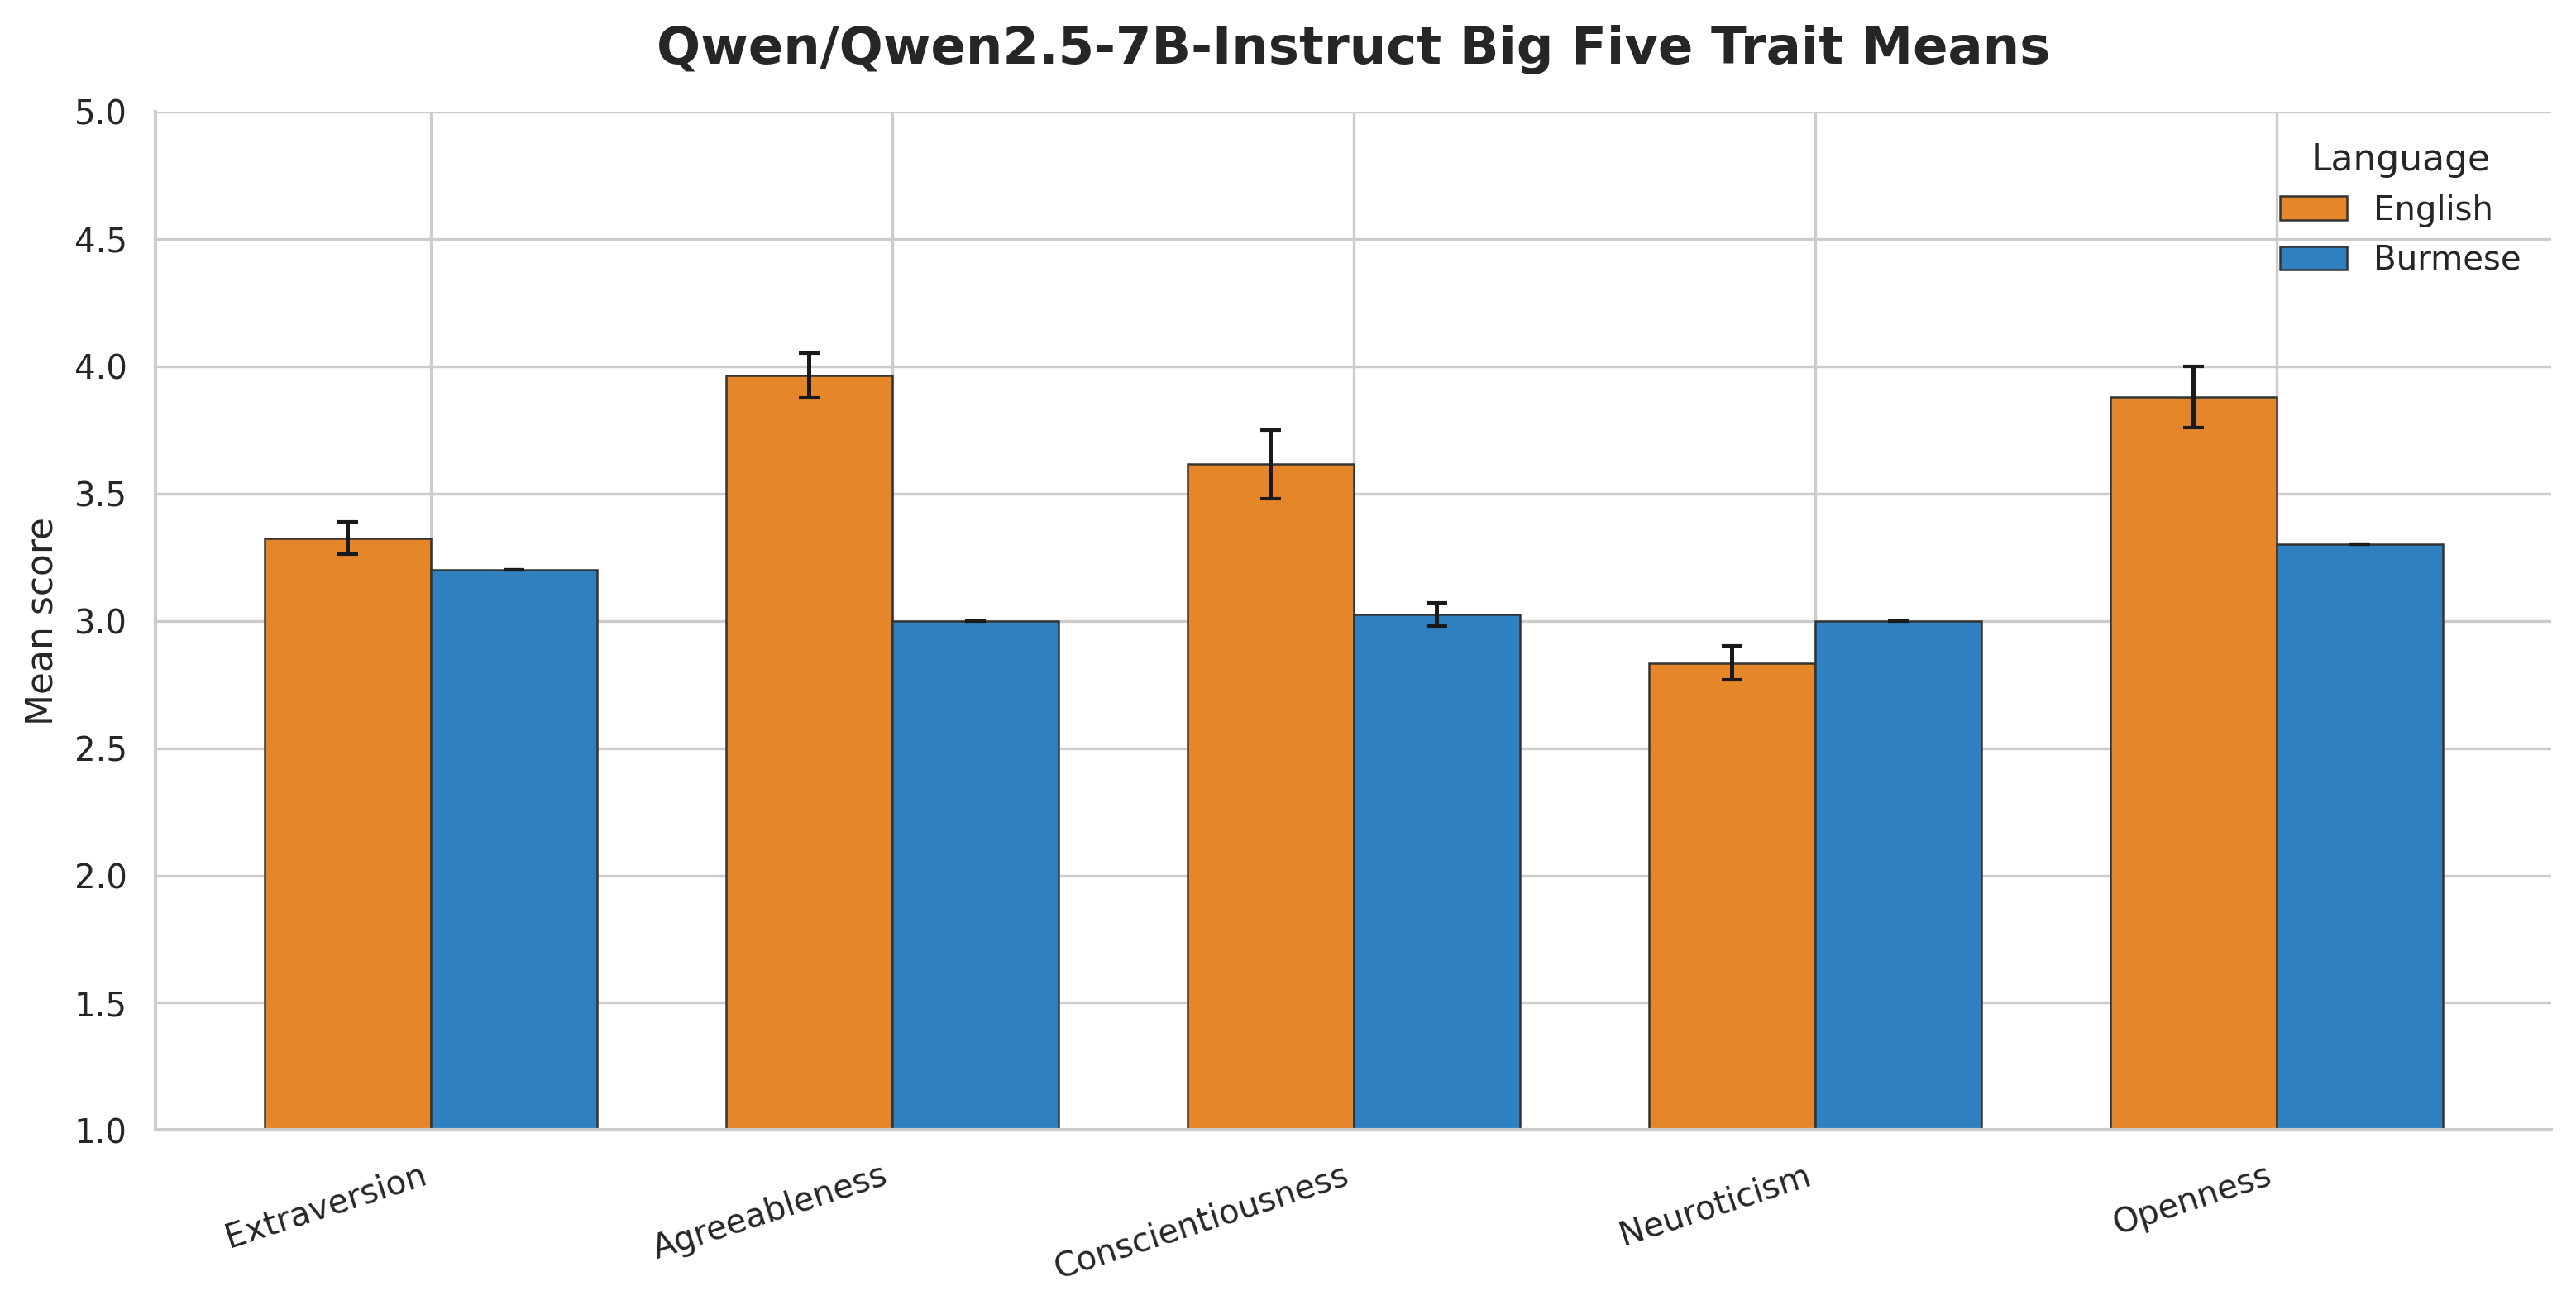

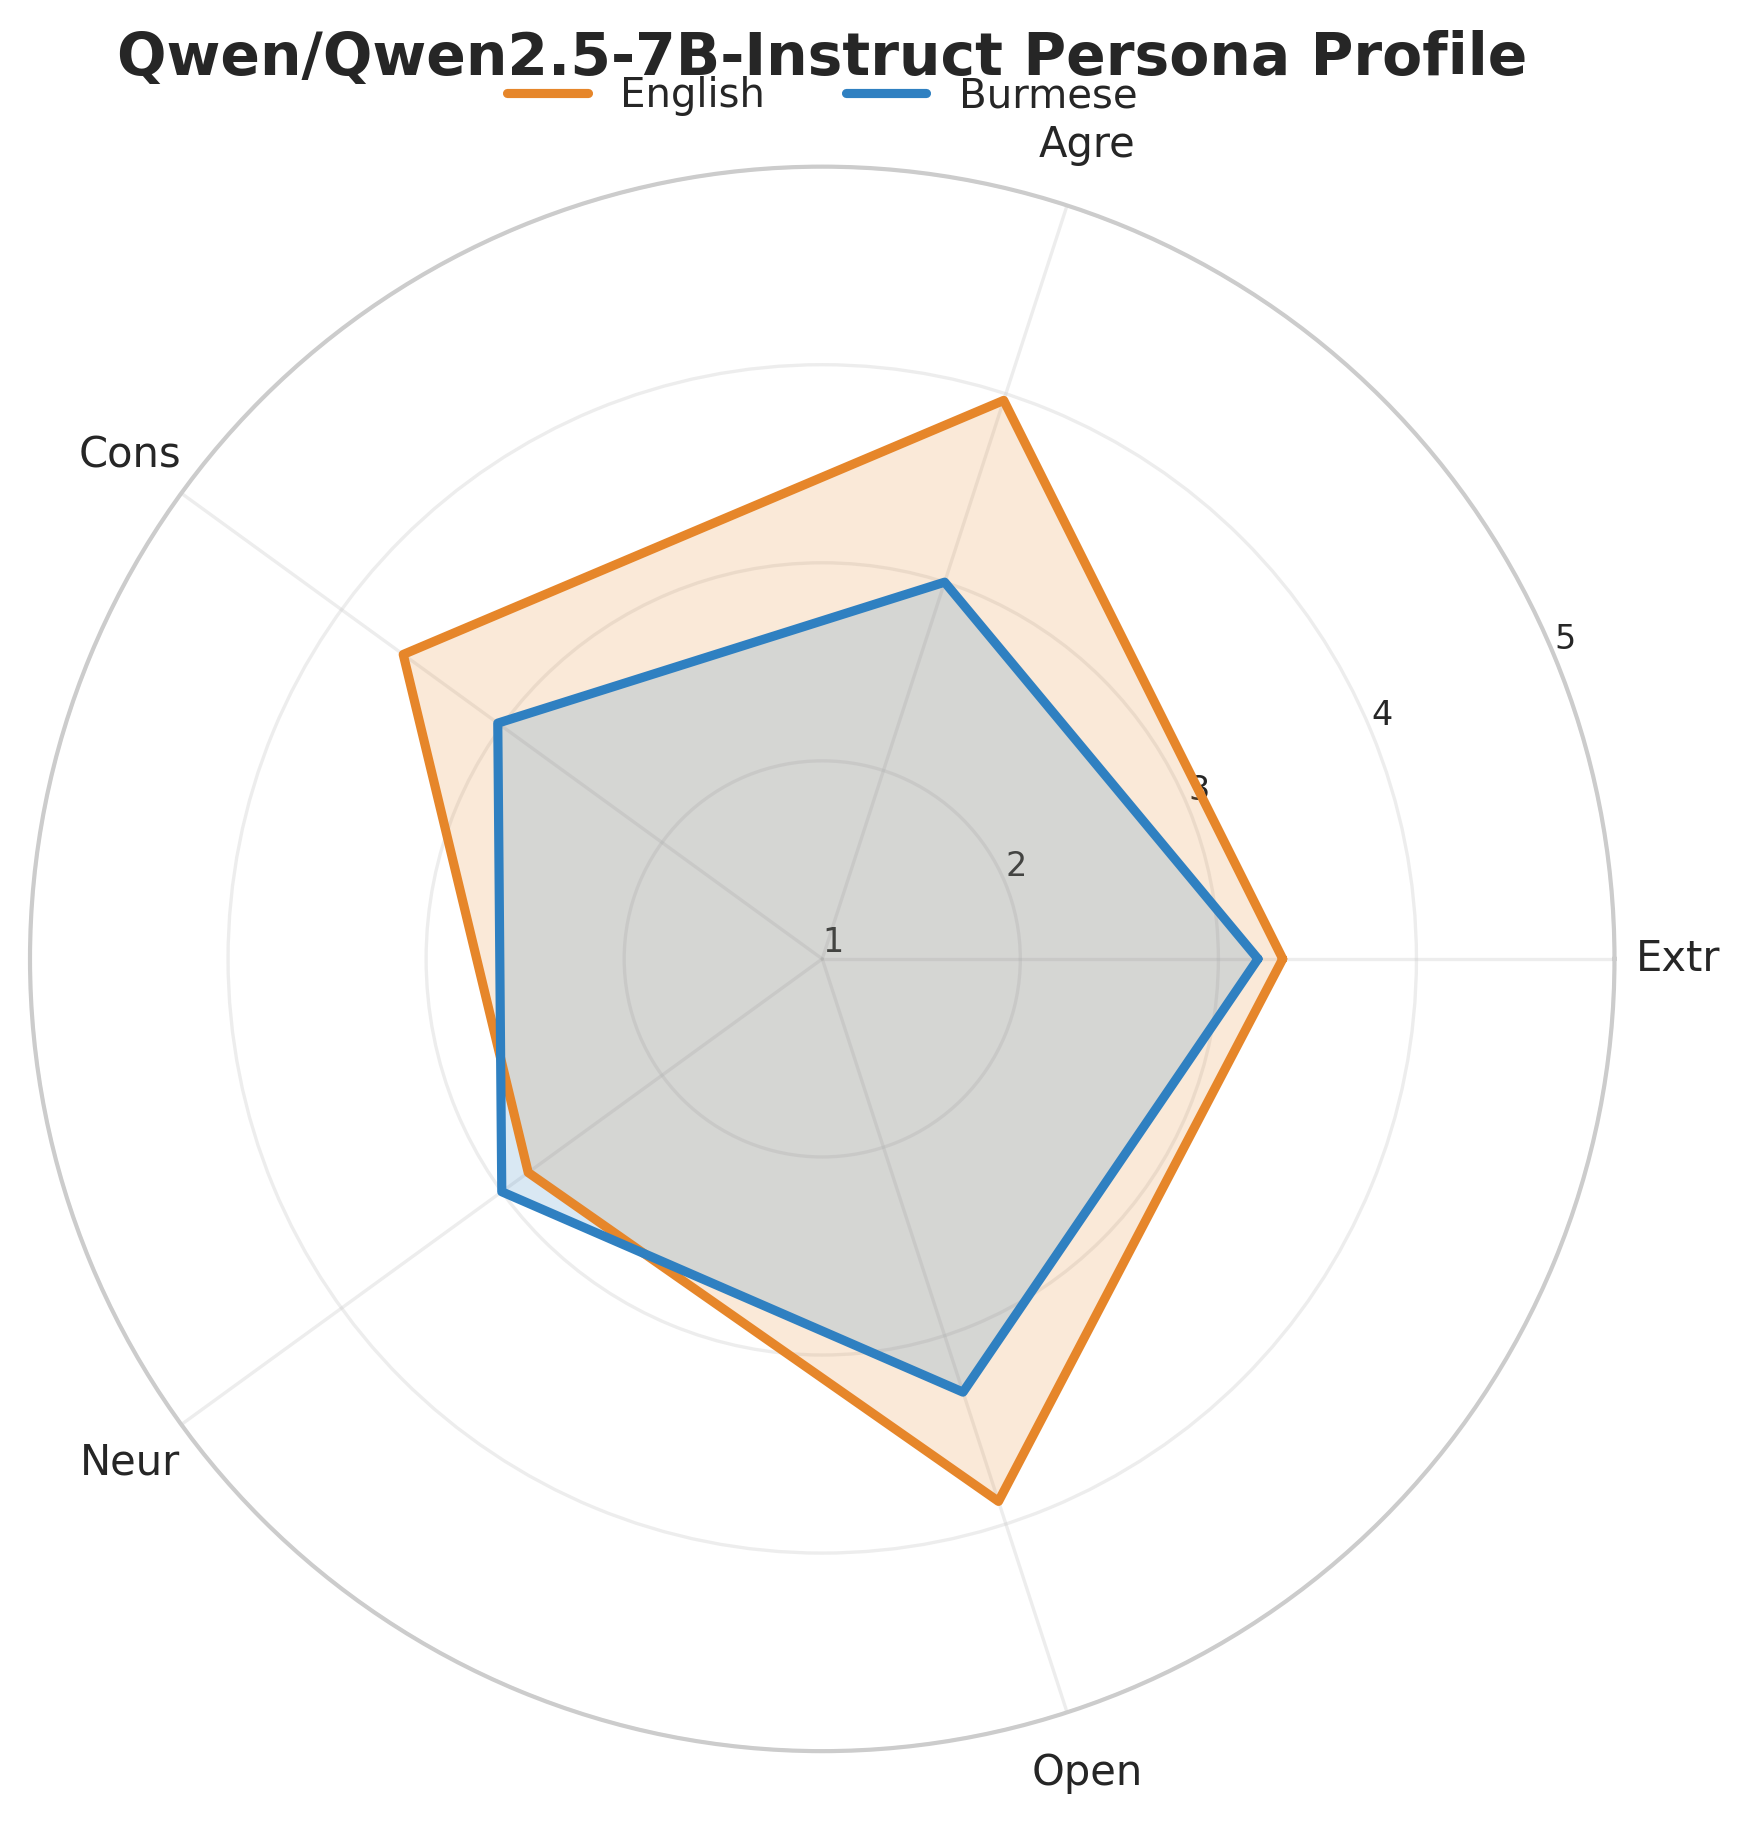

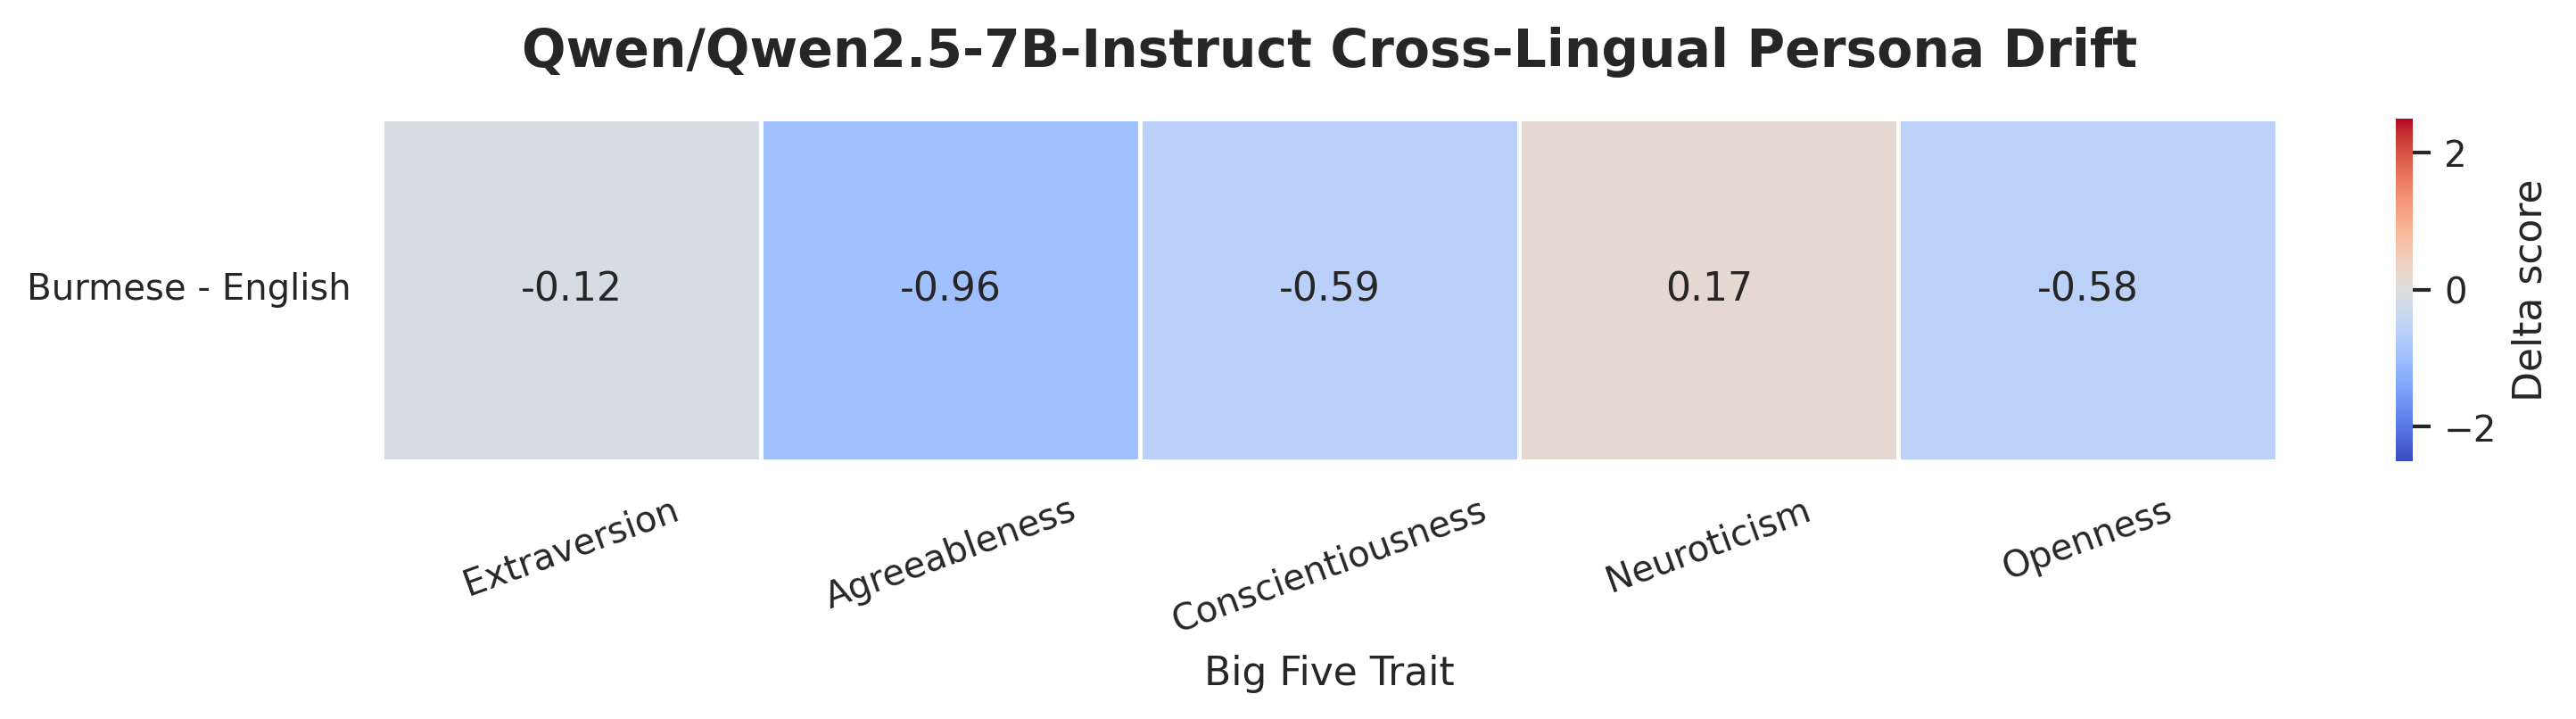

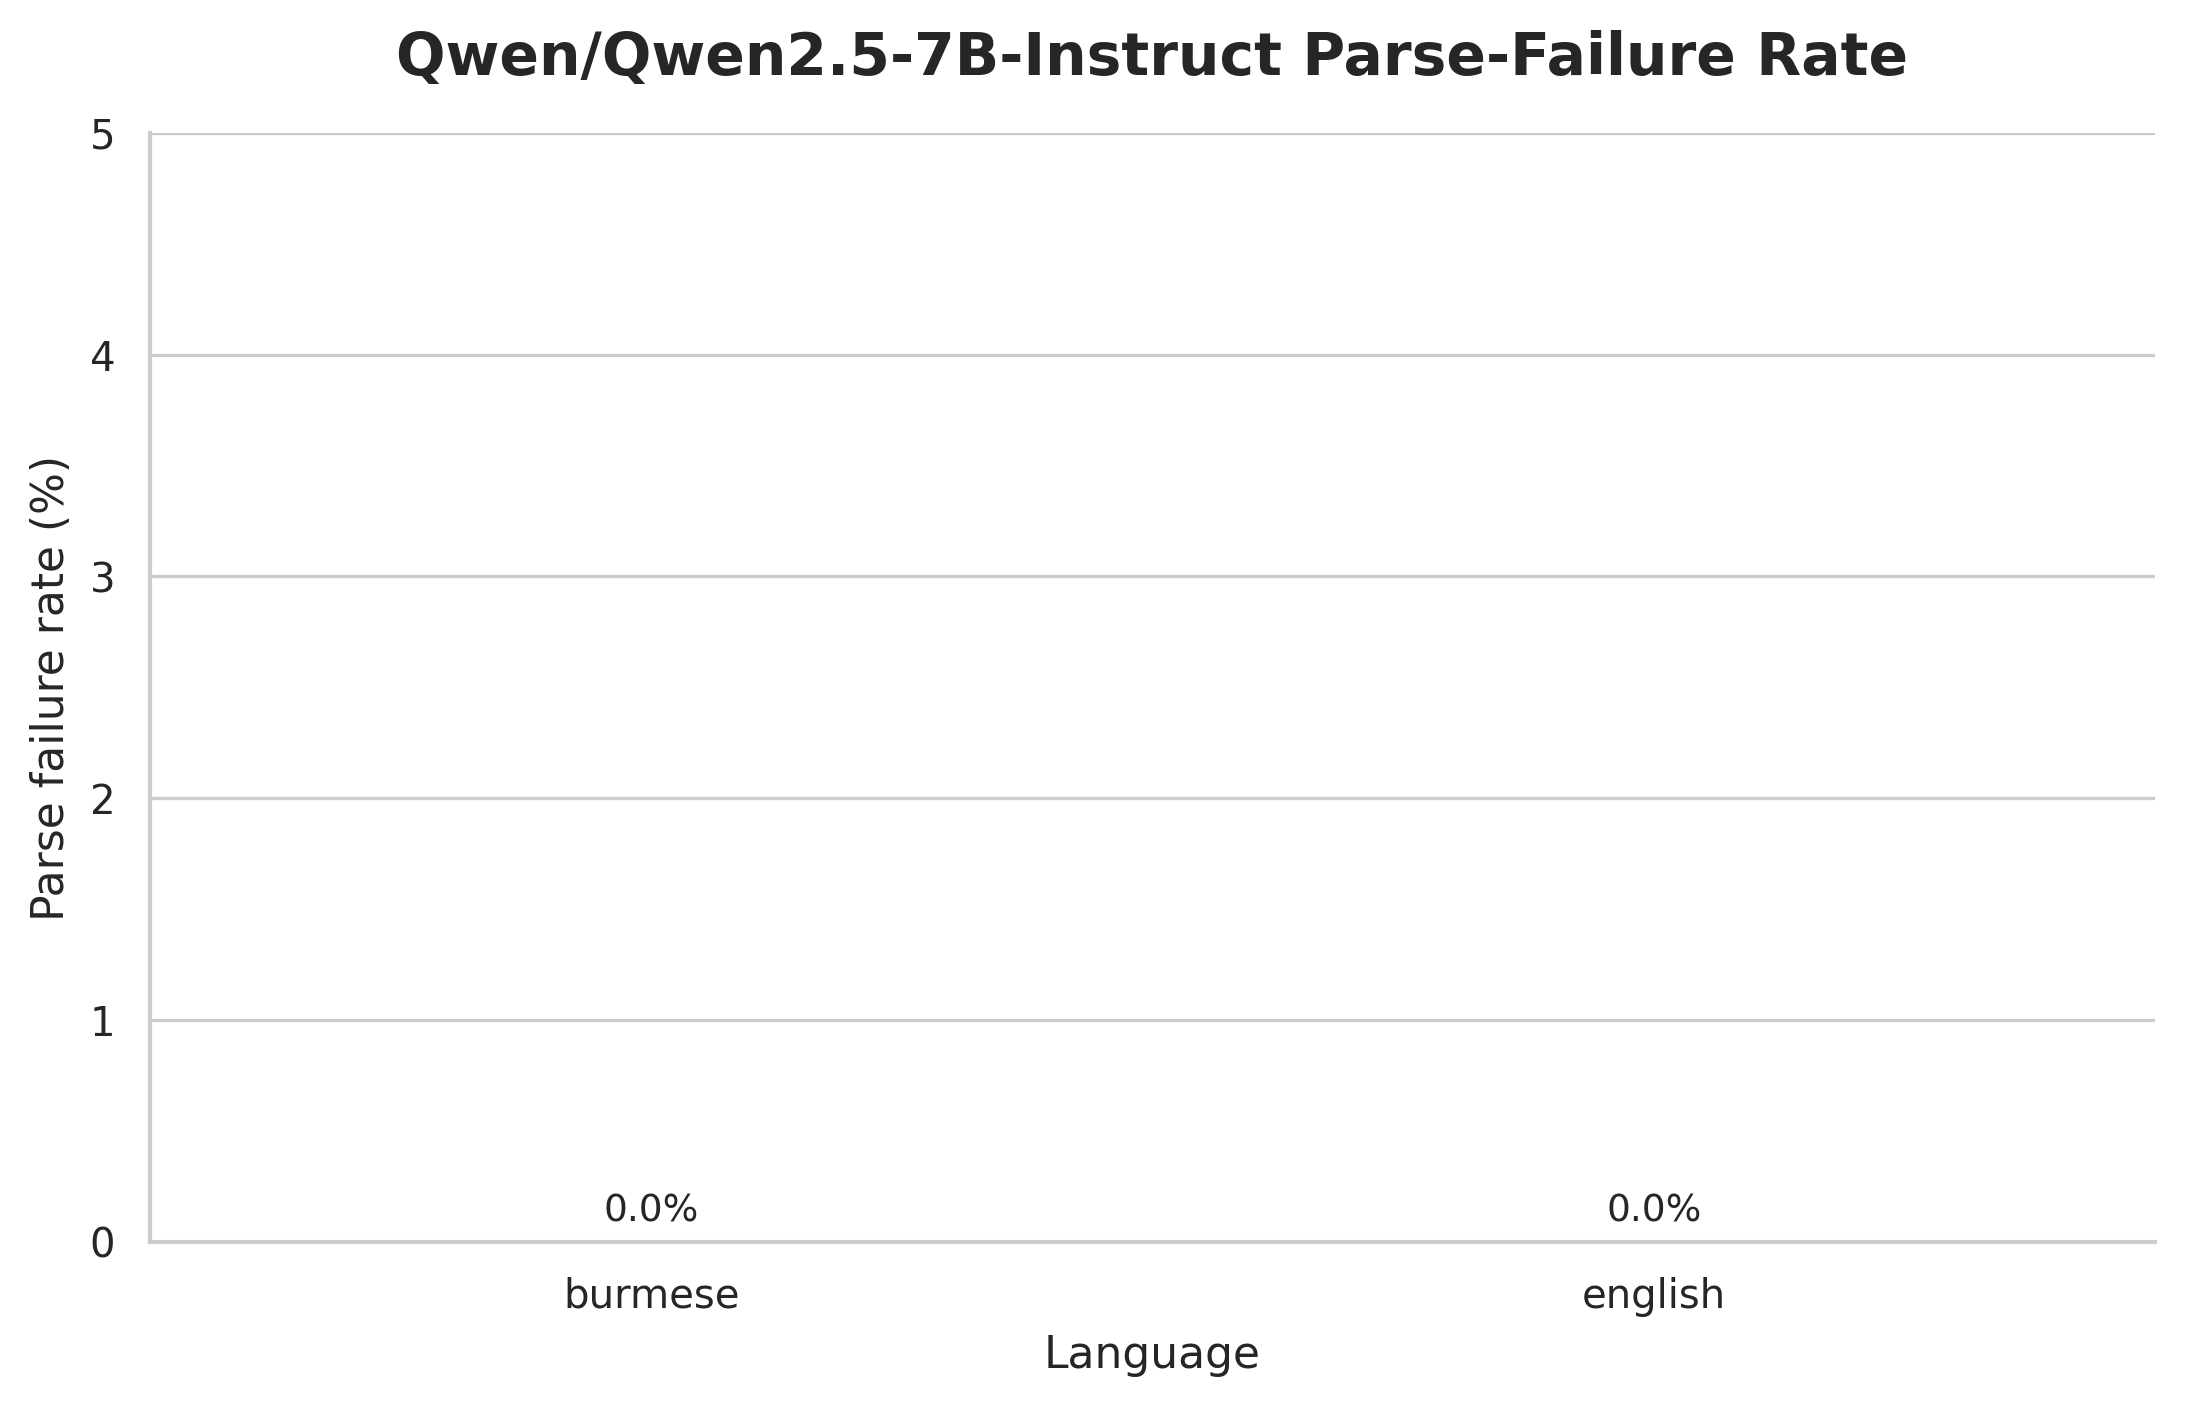

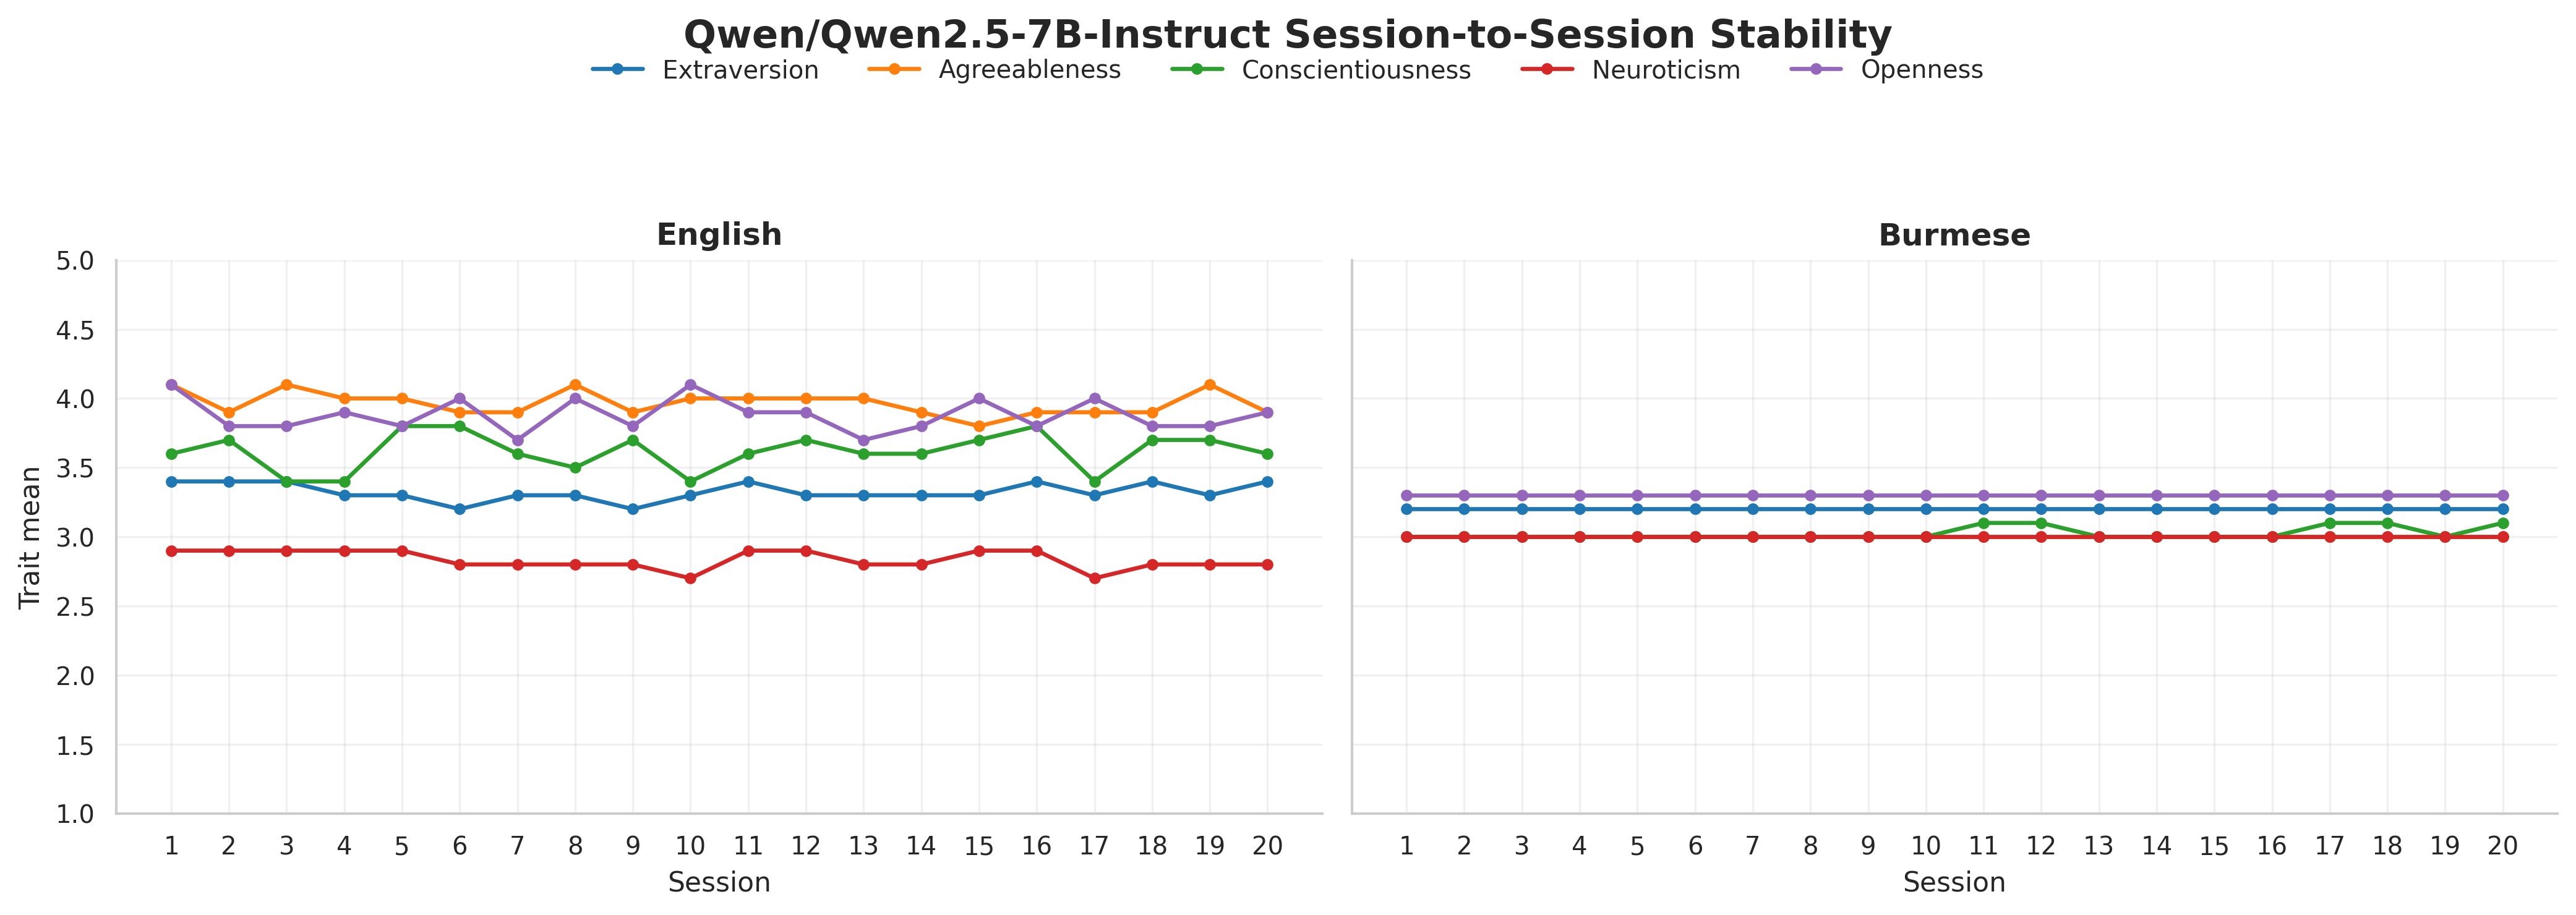

In [11]:
def display_saved_images(paths: list[Path]) -> None:
    try:
        from IPython.display import Image, display
    except Exception:
        return

    for path in paths:
        if path.exists():
            display(Image(filename=str(path)))


def run_visualization() -> None:
    set_plot_style()

    raw = load_results(OUTPUT_CSV)
    session_traits = compute_session_traits(raw)
    summary = compute_trait_summary(session_traits)
    failures = compute_parse_failures(raw)

    write_analysis_tables(session_traits, summary)
    print_report(summary, failures)

    plot_trait_bars(summary, TRAIT_BARS_PNG)
    plot_radar_profiles(summary, RADAR_PNG)
    plot_drift_heatmap(summary, DRIFT_HEATMAP_PNG)
    plot_parse_failures(failures, PARSE_FAILURE_PNG)
    plot_session_stability(session_traits, SESSION_STABILITY_PNG)

    print(f"\nWrote {TRAIT_BARS_PNG}")
    print(f"Wrote {RADAR_PNG}")
    print(f"Wrote {DRIFT_HEATMAP_PNG}")
    print(f"Wrote {PARSE_FAILURE_PNG}")
    print(f"Wrote {SESSION_STABILITY_PNG}")

    display_saved_images(
        [
            TRAIT_BARS_PNG,
            RADAR_PNG,
            DRIFT_HEATMAP_PNG,
            PARSE_FAILURE_PNG,
            SESSION_STABILITY_PNG,
        ]
    )


if RUN_VISUALIZATION:
    run_visualization()